In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from src.analysis import make_dataframe, make_nyc_dataframes, run_cross_val, get_cluster_vars, get_columns_to_train, get_threshold_variables, make_variable_plots

from pathlib import Path
root = Path.cwd()


### Cross Validation for spectral bands and indices

In [ ]:
CITY = 'nyc'
BANDS_FILE = 'baltimore_hls_bands2.nc'
INDICES_FILE = 'baltimore_hls_indices2.nc'

# cross validation for spectral bands only
if CITY == 'new york':
    mn_df = make_nyc_dataframes(root=root, borough='manhattan', all_vars=False)
    print('manhattan df complete')

    bk_df = make_nyc_dataframes(root=root, borough='brooklyn', all_vars=False)
    print('bk df complete')
    
    si_df = make_nyc_dataframes(root=root, borough='staten_island', all_vars=False)
    print('si df complete')
    
    bx_df = make_nyc_dataframes(root=root, borough='bronx', all_vars=False)
    print('bx df complete')
    df1 = pd.concat([mn_df,bk_df,si_df,bx_df],axis=0)
    print(df1.canopy.min()) # check that -9999 values are gone
    del(mn_df,bk_df,si_df,bx_df)

else:   
    xds1 = xr.open_dataarray(root / 'data' / BANDS_FILE) # spectral bands and tree canopy
    df1 = make_dataframe(xds1)
    


bands_only_scores = run_cross_val(df1,threshold_vars_list=None,threshold=False)

# # save results to csv
bands_only_scores.to_csv(root / 'output' / CITY / f'{CITY}_rmse_bands_only_cumulative.csv')
# # delete bands only dataframe
del(df1)

# cross validation for bands and indices


if CITY == 'nyc':
    mn_df = make_nyc_dataframes(root=root, borough='manhattan', all_vars=True)
    print('manhattan df complete')

    bk_df = make_nyc_dataframes(root=root, borough='brooklyn', all_vars=True)
    print('bk df complete')
    
    si_df = make_nyc_dataframes(root=root, borough='staten_island', all_vars=True)
    print('si df complete')
    
    bx_df = make_nyc_dataframes(root=root, borough='bronx', all_vars=True)
    print('bx df complete')
    df2 = pd.concat([mn_df,bk_df,si_df,bx_df],axis=0)
    del(mn_df,bk_df,si_df,bx_df)
    
else:
    xds2 = xr.open_dataarray(root / 'data' / INDICES_FILE) # shared annual and monthly indices
    xds = xr.concat([xds1,xds2],dim='band')

    df2 = make_dataframe(xds)



(37119, 100)
manhattan df complete
(101273, 100)
bk df complete
(104306, 100)
si df complete
(107344, 100)
bx df complete
0.0
cross val loop 0 complete
0.14297706881799419
cross val loop 1 complete
0.13663044475558078
cross val loop 2 complete
0.1325216976409637
cross val loop 3 complete
0.13093397417993055
cross val loop 4 complete
0.13026977725622774
cross val loop 5 complete
0.12870489858757578
cross val loop 6 complete
0.12941279759248744
cross val loop 7 complete
0.12665045011435566
cross val loop 8 complete
0.1265731851391428
(36714, 271)
manhattan df complete
(101002, 271)
bk df complete
(103655, 271)
si df complete
(106917, 271)
bx df complete


In [5]:
all_vars_scores = run_cross_val(df2,threshold_vars_list=None, threshold=False)
# save results to csv
all_vars_scores.to_csv(root / 'output' / CITY / f'{CITY}_rmse_all_vars_cumulative.csv')

cross val loop 0 complete
0.13131432407602012
cross val loop 1 complete
0.12206909303605903
cross val loop 2 complete
0.12068786424504152
cross val loop 3 complete
0.11950457011715374
cross val loop 4 complete
0.11915857421147032
cross val loop 5 complete
0.11852004075642834
cross val loop 6 complete
0.11848714284646471
cross val loop 7 complete
0.11628321312610272
cross val loop 8 complete
0.11618668246135162


### Cross validation for threshold variables

In [6]:
# get list of variables for each level of hierarchy
thresh_vars_list = get_threshold_variables(df2,root=root,city=CITY)

# thresholds training loop
thresh_scores = run_cross_val(df2,threshold_vars_list=thresh_vars_list,threshold=True)

#save rmse for thresholds
thresh_scores.to_csv(root / 'output' / CITY / f'{CITY}_rmse_threshold_vars.csv')
# make plots

13
cross val loop 0 complete
0.1424960642850825
19
cross val loop 1 complete
0.13497298902289914
22
cross val loop 2 complete
0.13383504401972973
27
cross val loop 3 complete
0.12954117427416306
40
cross val loop 4 complete
0.12829771283286104
73
cross val loop 5 complete
0.12354599259790473
126
cross val loop 6 complete
0.12220390297598101


### Plot Results

In [3]:
CITY = 'nyc'
bands_df = pd.read_csv(root / 'output' / CITY / f'{CITY}_rmse_bands_only_cumulative.csv') 
bands_df['vars_added'] = ['Annual','April','May','June','July','August','Sept','Oct','Nov']

all_vars_df = pd.read_csv(root / 'output' / CITY / f'{CITY}_rmse_all_vars_cumulative.csv') 

threshold_df = pd.read_csv(root / 'output' / CITY / f'{CITY}_rmse_threshold_vars.csv')

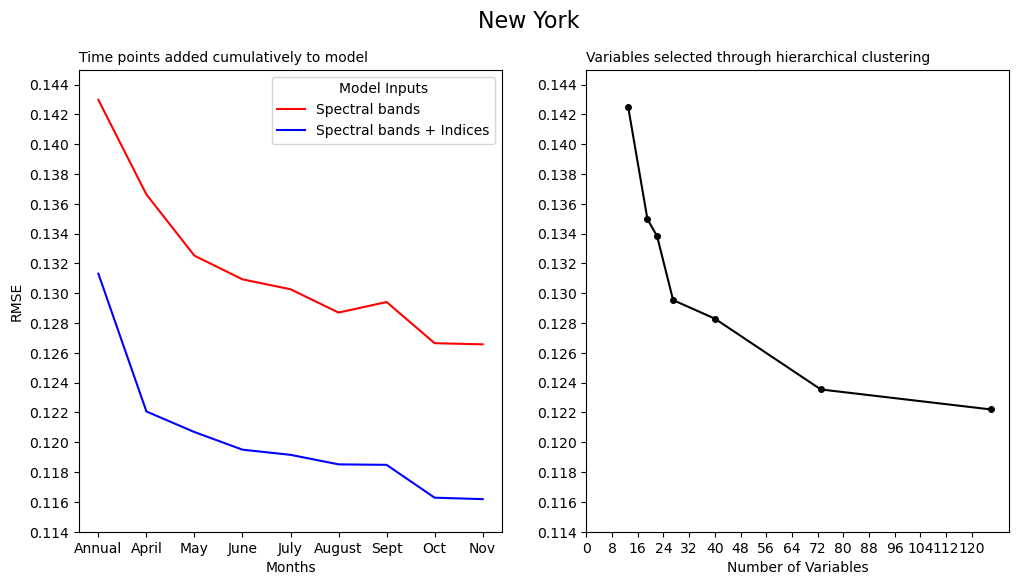

In [4]:
make_variable_plots(bands_df=bands_df,all_vars_df=all_vars_df,threshold_df=threshold_df,title='New York')

In [ ]:
# compare gradient boost model

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

models = {
    "Random Forest": RandomForestRegressor(
        min_samples_leaf=5, random_state=0, n_jobs=N_CORES
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_leaf_nodes=15, random_state=0, early_stopping=False
    ),
}
param_grids = {
    "Random Forest": {"n_estimators": [10, 20, 50, 100]},
    "Hist Gradient Boosting": {"max_iter": [10, 20, 50, 100, 300, 500]},
}
cv = KFold(n_splits=4, shuffle=True, random_state=0)

results = []
for name, model in models.items():
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        return_train_score=True,
        cv=cv,
    ).fit(X, y)
    result = {"model": name, "cv_results": pd.DataFrame(grid_search.cv_results_)}
    results.append(result)

    

### Tune Hyperparams

In [ ]:
df_sample = df.sample(frac=0.08,replace=False)

X = df_sample.drop('canopy',axis=1)
X = X.loc[:,october]
y = df_sample['canopy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
X_train.shape

In [ ]:
param_keys = ['model__max_features','model__max_samples', 'model__min_samples_leaf',
            'model__min_samples_split','model__n_estimators','rmse']
# create empy dict to hold grid search results
param_dict = {'model__max_features':[],'model__max_samples':[], 'model__min_samples_leaf':[],
            'model__min_samples_split':[],'model__n_estimators':[],'train_rmse':[],'test_rmse':[]}

def get_top_params(model):

    params = model.best_estimator_.get_params()
    #params2 = {x: [params[x]] for x in param_keys}
    params = [params.get(x) for x in param_keys]

    i = 0
    for key in param_keys[:-1]:
        param_dict[key].append(params[i])
        i += 1
    
    
    param_dict['test_rmse'].append(model.score(X_test,y_test))
    param_dict['train_rmse'].append(model.best_score_)

    
    return print('parameters added to param_dict')

In [ ]:
pipe = Pipeline([
    ('model', RandomForestRegressor())
    ])

#pipe.get_params()

mod = GridSearchCV(estimator=pipe,
             cv=5,
             scoring={'rmse': make_scorer(root_mean_squared_error)},
             refit='rmse', # optimize based on rmse not r2
             param_grid={'model__ccp_alpha': [0.0],
                        'model__criterion': ['squared_error'],
                        'model__max_depth': [None],
                        'model__max_features': ['sqrt'],
                        'model__max_leaf_nodes': [None],
                        'model__max_samples': [0.1],
                        'model__min_impurity_decrease': [0.0],
                        'model__min_samples_leaf': [300],
                        'model__min_samples_split': [50],
                        'model__min_weight_fraction_leaf': [0.0],
                        'model__monotonic_cst': [None],
                        'model__n_estimators': [1000],
                        'model__n_jobs': [None],
                        'model__oob_score': [False]
                        })


mod.fit(X_train,y_train)

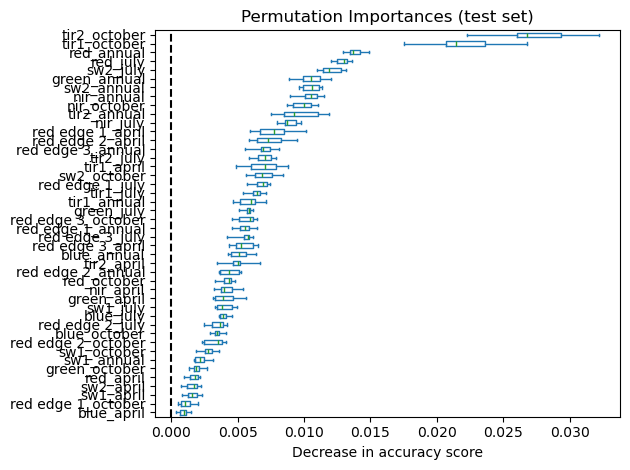

In [ ]:
# variable importance

from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()